In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
iris_data = load_iris()

In [3]:
iris_df = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)
iris_df['species'] = iris_data.target
iris_df['species'] = iris_df['species'].map({i: name for i, name in enumerate(iris_data.target_names)})
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
input_columns = list(iris_df.iloc[:,:4].columns)
input_columns.sort()
input_data = iris_df[input_columns]
input_data.head()

,petal length (cm),petal width (cm),sepal length (cm),sepal width (cm)
0,1.4,0.2,5.1,3.5
1,1.4,0.2,4.9,3.0
2,1.3,0.2,4.7,3.2
3,1.5,0.2,4.6,3.1
4,1.4,0.2,5.0,3.6


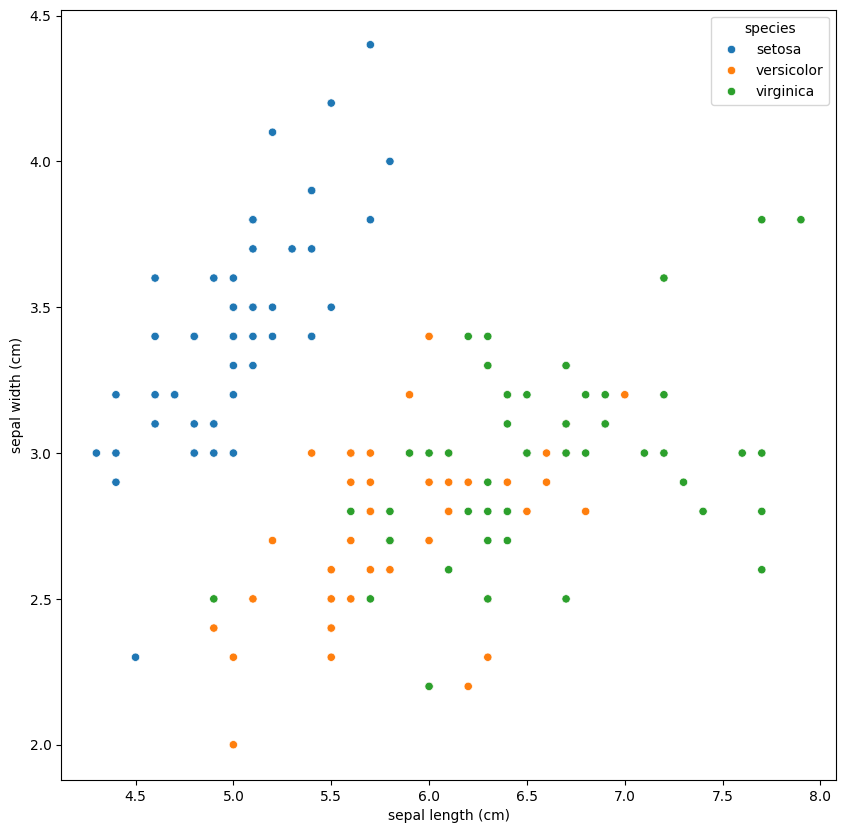

In [5]:
plt.subplots(figsize=(10,10))
sns.scatterplot(x = 'sepal length (cm)', y = 'sepal width (cm)', hue = 'species', data = iris_df)
plt.show()

In [6]:
scaler = StandardScaler()
input_data = scaler.fit_transform(input_data)
input_data = pd.DataFrame(data=input_data, columns=input_columns)
input_data.head()

,petal length (cm),petal width (cm),sepal length (cm),sepal width (cm)
0,-1.340227,-1.315444,-0.900681,1.019004
1,-1.340227,-1.315444,-1.143017,-0.131979
2,-1.397064,-1.315444,-1.385353,0.328414
3,-1.283389,-1.315444,-1.506521,0.098217
4,-1.340227,-1.315444,-1.021849,1.249201


In [8]:
u, s, v = np.linalg.svd(input_data, full_matrices=True)
exp_var = s**2 / np.sum(s**2)*100
pc = iris_df[input_columns].dot(v.T)
pc.columns = ['PC1', 'PC2', 'PC3', 'PC4']
pc['species'] = iris_df.species
pc.head()

,PC1,PC2,PC3,PC4,species
0,2.640270,-5.204041,2.488621,0.117033,setosa
1,2.670730,-4.666910,2.466898,0.107536,setosa
2,2.454606,-4.773636,2.288321,0.104350,setosa
3,2.545517,-4.648463,2.212378,0.278417,setosa
4,2.561228,-5.258629,2.392226,0.155513,setosa


In [9]:
exp_var

array([72.96244541, 22.85076179,  3.66892189,  0.51787091])

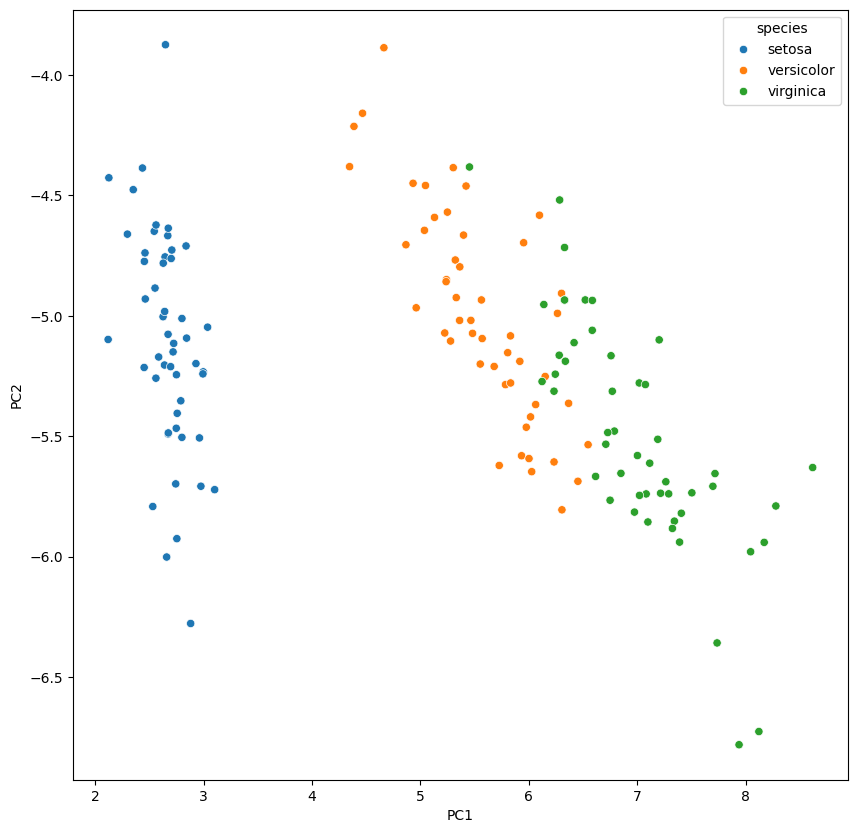

In [10]:
plt.subplots(figsize=(10,10))
sns.scatterplot(x = 'PC1', y = 'PC2', hue = 'species', data = pc)
plt.show()

In [12]:
PCA_Sklearn = PCA(n_components=0.95)
principalComponents = PCA_Sklearn.fit_transform(iris_df.iloc[:,:4])
principalDf = pd.DataFrame(data = principalComponents, columns = ['PC1', 'PC2'])
principalDf

,PC1,PC2
0,-2.684126,0.319397
1,-2.714142,-0.177001
2,-2.888991,-0.144949
3,-2.745343,-0.318299
4,-2.728717,0.326755
...,...,...
145,1.944110,0.187532
146,1.527167,-0.375317
147,1.764346,0.078859
148,1.900942,0.116628


In [13]:
projected_data_sklearn_df_with_class_info = pd.concat([principalDf, iris_df[['species']]], axis = 1)
print("Explained Variance\n")
print(PCA_Sklearn.explained_variance_ratio_)

Explained Variance

[0.92461872 0.05306648]


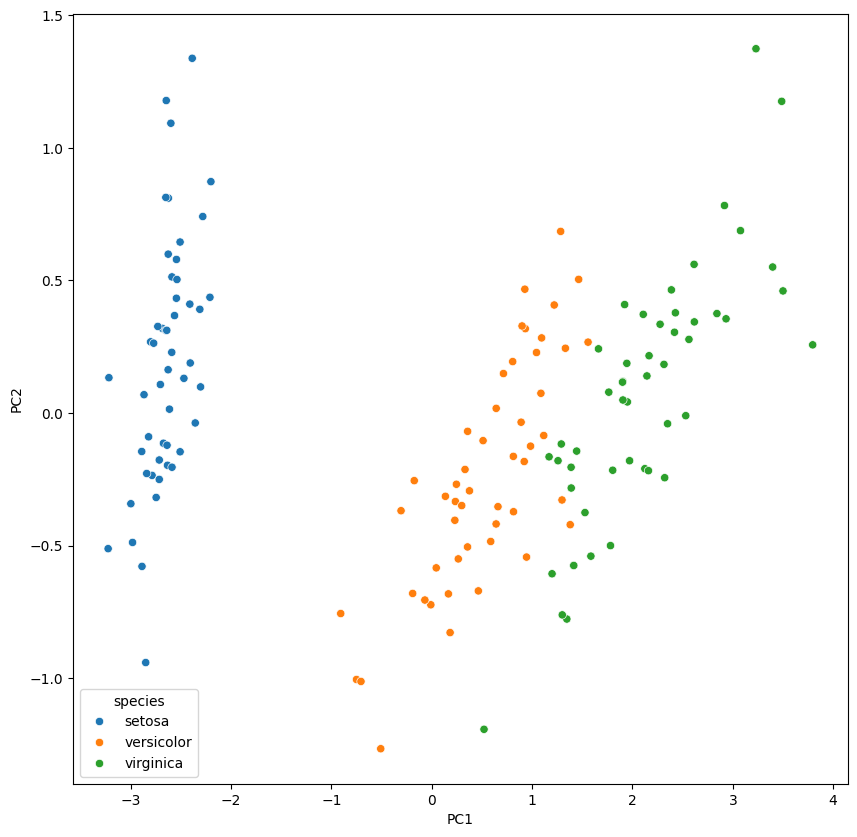

In [14]:
plt.subplots(figsize=(10,10))
sns.scatterplot(x = 'PC1', y = 'PC2', hue = 'species', data = projected_data_sklearn_df_with_class_info)
plt.show()